In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo


In [2]:
from pathlib import Path

UTC_TZ = ZoneInfo("UTC")
ARIZONA_TZ = ZoneInfo("America/Phoenix")

def convert_utc_to_arizona_index(df, timestamp_col="timestamp"):
    df = df.copy()

    if timestamp_col in df.columns:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True).dt.tz_convert(ARIZONA_TZ)
    else:
        df.index = pd.to_datetime(df.index, utc=True).tz_convert(ARIZONA_TZ)

    return df

# Use the processed file only to recover the expected column names.
df = pd.read_csv(
    "datasets/raw_data/INRIX_SPEED_AZ/processed/processed.csv",
    parse_dates=[0]
)
# df = df.set_index("timestamp").sort_index() * 1.61

input_dir = Path("datasets/raw_data/INRIX_SPEED_AZ/processed")
reference_files = {
    f"out_{path.name.replace('input_', '')}": path
    for path in sorted(input_dir.glob("input_*.csv"))
}

incident_path = input_dir / "incidents.csv"

incident_df = pd.read_csv(incident_path, parse_dates=["timestamp"])
incident_df = convert_utc_to_arizona_index(incident_df, timestamp_col="timestamp")
incident_df = incident_df.set_index("timestamp").sort_index()

ref_dfs = {}
for output_file, ref_file in reference_files.items():
    ref_df = pd.read_csv(
        ref_file,
        header=None,
        parse_dates=[0]
    )
    ref_df.columns = df.columns
    ref_df = convert_utc_to_arizona_index(ref_df)
    ref_dfs[output_file] = ref_df.set_index("timestamp").sort_index() * 1.61

# ref_dfs["out_weekday1.csv"],max(axis=1)

In [3]:
# incident_df.reindex(ref_df.index)

In [4]:
output_dir = Path("exp2_gwnet")
output_files = {
    output_file: output_dir / output_file
    for output_file in reference_files
    if (output_dir / output_file).exists()
}

aligned_outputs = {}
aligned_incidents = {}

for output_file, output_path in output_files.items():
    ref_df = ref_dfs[output_file]
    df = pd.read_csv(output_path, header=None, parse_dates=[0])
    df.columns = ref_df.reset_index().columns
    df = convert_utc_to_arizona_index(df, timestamp_col=df.columns[0])
    df = df.set_index(df.columns[0]).sort_index() * 1.61
    
    df_aligned = df.reindex(ref_df.index)
    
    # offset by 5 mins
    # df_aligned.index = df_aligned.index - pd.Timedelta(minutes=5)
    
    aligned_outputs[output_file] = df_aligned
    aligned_incidents[output_file] = incident_df.reindex(ref_df.index).fillna(0)

In [5]:
def plot_segment_predictions(
    segment_id,
    output_file,
    start=None,
    end=None,
    date_range=None,
    n_points=None,
    interval=3,
):
    """
    Plot predictions vs ground truth for a segment.

    Parameters
    ----------
    segment_id : str
    start : str or datetime, optional
        Start date for subset
    end : str or datetime, optional
        End date for subset
    date_range : tuple[str | datetime, str | datetime], optional
        Convenience alias for (start, end)
    n_points : int, optional
        Plot only last N timestamps after date filtering
    """

    ref_df = ref_dfs[output_file]

    # Ground truth
    dfs = [
        ref_df[[segment_id]].rename(columns={segment_id: "Ground Truth"})
    ]

    # Add model predictions
    df = aligned_outputs[output_file]
    # model_name = output_file.replace("out_", "").replace(".csv", "")
    dfs.append(df[[segment_id]].rename(columns={segment_id: "Prediction"}))

    # Align and clean
    combined = pd.concat(dfs, axis=1, join="inner").dropna()

    # ---- Subset logic ----
    if date_range is not None:
        if len(date_range) != 2:
            raise ValueError("date_range must be a (start, end) pair.")
        start, end = date_range

    if start is not None or end is not None:
        start_ts = pd.Timestamp(start) if start is not None else None
        end_ts = pd.Timestamp(end) if end is not None else None

        if start_ts is not None and start_ts.tzinfo is None:
            start_ts = start_ts.tz_localize(ARIZONA_TZ)
        if end_ts is not None and end_ts.tzinfo is None:
            end_ts = end_ts.tz_localize(ARIZONA_TZ)

        combined = combined.loc[start_ts:end_ts]

    if n_points:
        combined = combined.tail(n_points)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))

    for col in combined.columns:
        ax.plot(combined.index, combined[col], label=col)

    ax.set_xlabel("Date")
    ax.set_ylabel("Speed (mph)")
    ax.set_title(f"Segment {segment_id}: Prediction vs Ground Truth")
    ax.legend()


    ax.xaxis.set_major_locator(mdates.HourLocator(interval=interval, tz=ARIZONA_TZ))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %m-%d %H:%M", tz=ARIZONA_TZ))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return combined

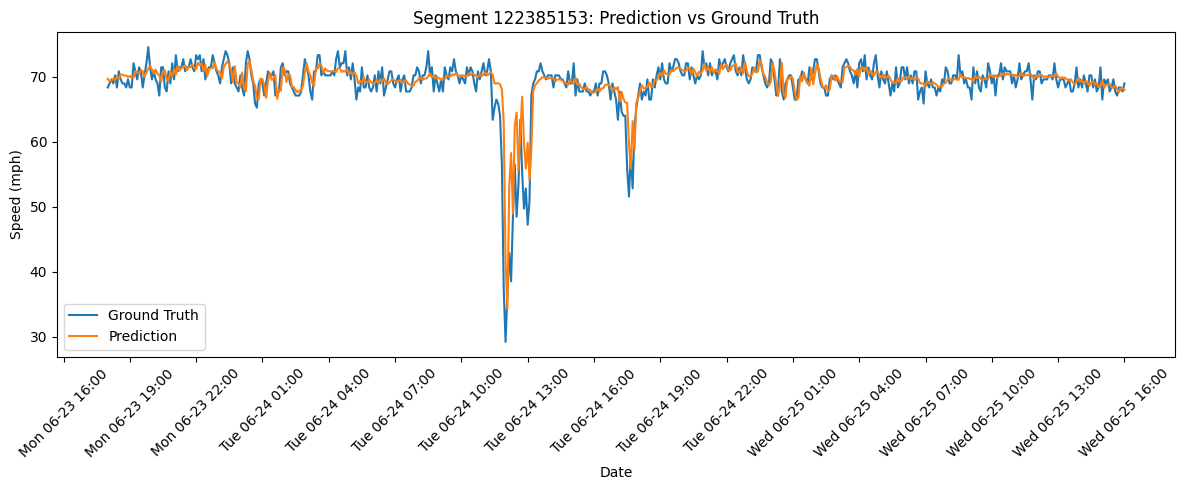

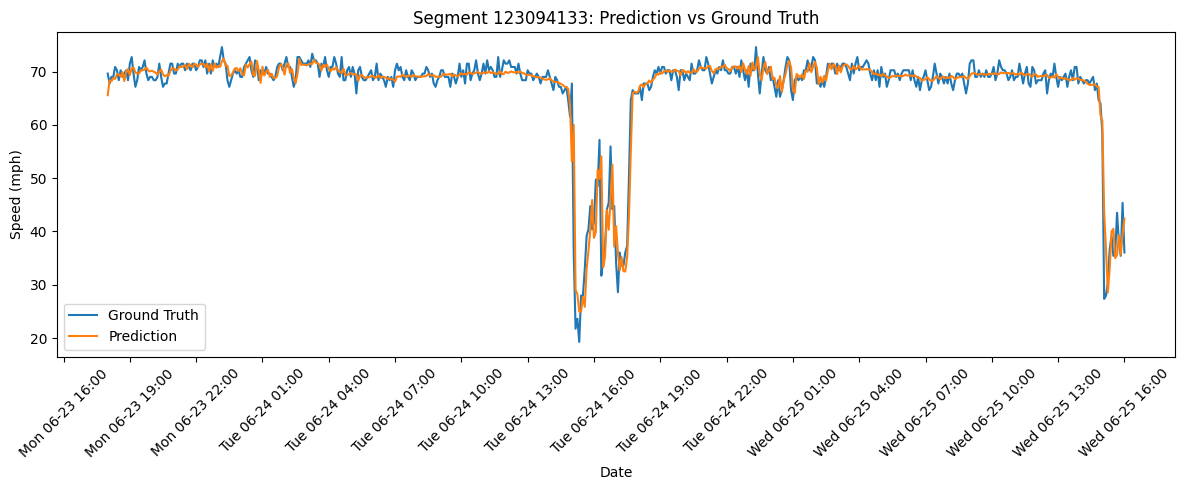

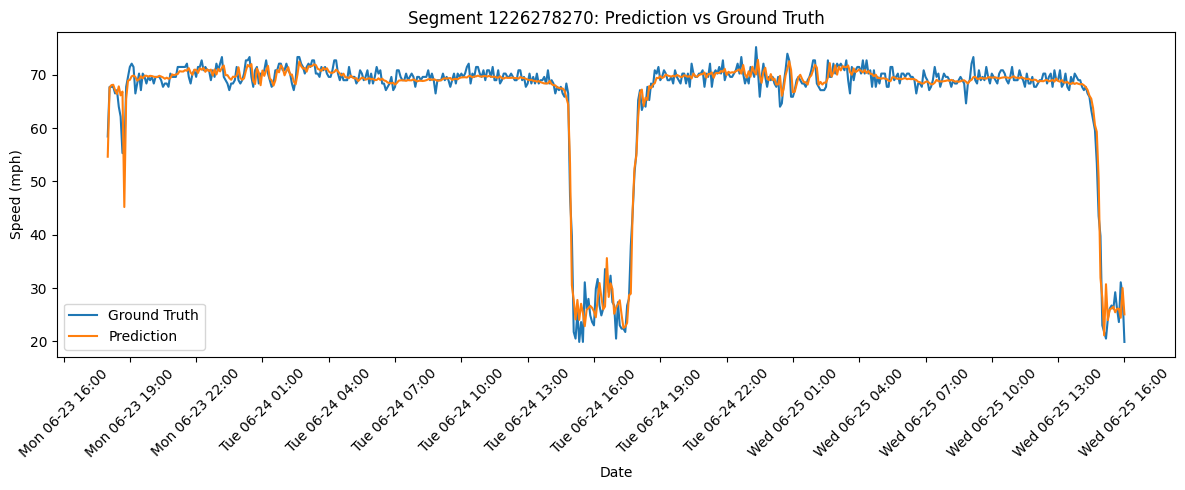

In [6]:
segments = [
    "122385153",
    "123094133",
    "1226278270",
]

for output_file in output_files:
    for segment in segments:
        plot_segment_predictions(
            segment_id=segment, 
            output_file=output_file,
            # date_range=("2025-06-28 10:00", "2025-06-28 18:00"),
            interval=3
        )

,122385153,123094133,440907446,440907447,448798645,448798652,448801792,450124719,450136781,450178140,...,1226274258,1226274301,1226274364,1226276233,1226278116,1226278118,1226278270,1226278279,1226278747,1626426438
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-23 17:00:00-07:00,65.892154,19.891971,46.621807,67.757026,69.000274,68.378650,69.000274,23.621715,19.270347,29.837956,...,59.054289,32.324453,61.540785,67.135402,71.486770,70.865146,19.270347,64.648905,68.378650,67.757026
2025-06-23 17:05:00-07:00,69.621898,24.864964,37.297445,69.000274,68.378650,70.243522,69.621898,24.243340,24.864964,28.594708,...,60.297537,54.702920,63.405657,69.000274,70.865146,70.865146,24.243340,66.513778,69.000274,68.378650
2025-06-23 17:10:00-07:00,68.378650,31.081205,47.865055,67.135402,67.757026,68.378650,68.378650,23.000091,20.513595,36.054197,...,60.297537,59.675913,60.297537,69.000274,69.621898,68.378650,24.243340,63.405657,67.135402,64.027281
2025-06-23 17:15:00-07:00,70.865146,32.946077,54.081296,65.892154,71.486770,66.513778,67.757026,32.324453,26.729836,32.324453,...,57.811040,46.621807,60.919161,67.135402,69.000274,70.865146,19.891971,59.675913,68.378650,66.513778
2025-06-23 17:20:00-07:00,67.757026,23.621715,52.838048,68.378650,73.351643,69.000274,68.378650,33.567701,32.324453,32.324453,...,49.108303,34.189325,62.784033,68.378650,72.108395,72.108395,25.486588,28.594708,67.135402,66.513778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25 16:35:00-07:00,67.757026,34.189325,49.729927,65.270530,67.757026,66.513778,60.297537,24.243340,18.027099,21.756843,...,40.405566,14.297354,65.270530,67.135402,73.973267,70.865146,21.756843,66.513778,65.892154,66.513778
2025-06-25 16:40:00-07:00,70.243522,37.297445,48.486679,61.540785,70.865146,67.757026,67.135402,11.189234,11.810858,31.081205,...,39.783942,17.405475,60.297537,67.757026,73.351643,73.973267,26.729836,67.135402,64.027281,66.513778
2025-06-25 16:45:00-07:00,68.378650,35.432573,49.729927,42.892062,71.486770,66.513778,67.135402,18.648723,18.027099,18.648723,...,47.243431,13.675730,60.919161,67.757026,72.108395,72.730019,23.621715,67.757026,67.135402,66.513778


In [11]:
# Residual summary by event/non-event and hour of day

hourly_residual_by_event = {}
hourly_residual_summary = []

for output_file in output_files:
    ref_df = ref_dfs[output_file]
    pred_df = aligned_outputs[output_file]
    incident_df = aligned_incidents[output_file]

    valid_columns = ref_df.columns.intersection(pred_df.columns).intersection(incident_df.columns)
    residual_df = pred_df[valid_columns] - ref_df[valid_columns]
    event_mask = incident_df[valid_columns].fillna(0).gt(0)

    residual_long = residual_df.stack().rename("residual").reset_index()
    residual_long.columns = ["timestamp", "segment_id", "residual"]

    event_long = event_mask.stack().rename("is_event").reset_index()
    event_long.columns = ["timestamp", "segment_id", "is_event"]

    merged = residual_long.merge(event_long, on=["timestamp", "segment_id"], how="inner")
    merged["event_type"] = merged["is_event"].map({True: "event", False: "non_event"})
    merged["hour_of_day"] = merged["timestamp"].dt.hour

    hourly_avg = (
        merged.groupby(["event_type", "hour_of_day"], as_index=False)["residual"]
        .mean()
        .sort_values(["event_type", "hour_of_day"])
    )

    hourly_residual_by_event[output_file] = hourly_avg

    summary = hourly_avg.copy()
    summary.insert(0, "output_file", output_file)
    hourly_residual_summary.append(summary)

hourly_residual_summary = pd.concat(hourly_residual_summary, ignore_index=True)
hourly_residual_summary


,output_file,event_type,hour_of_day,residual
0,out_weekday1.csv,event,0,-0.208817
1,out_weekday1.csv,event,1,-0.457080
2,out_weekday1.csv,event,2,0.312421
3,out_weekday1.csv,event,3,0.589313
4,out_weekday1.csv,event,4,0.056750
5,out_weekday1.csv,event,5,0.182209
6,out_weekday1.csv,event,6,-0.116498
7,out_weekday1.csv,event,7,0.424466
8,out_weekday1.csv,event,8,0.995909
9,out_weekday1.csv,event,9,0.103698


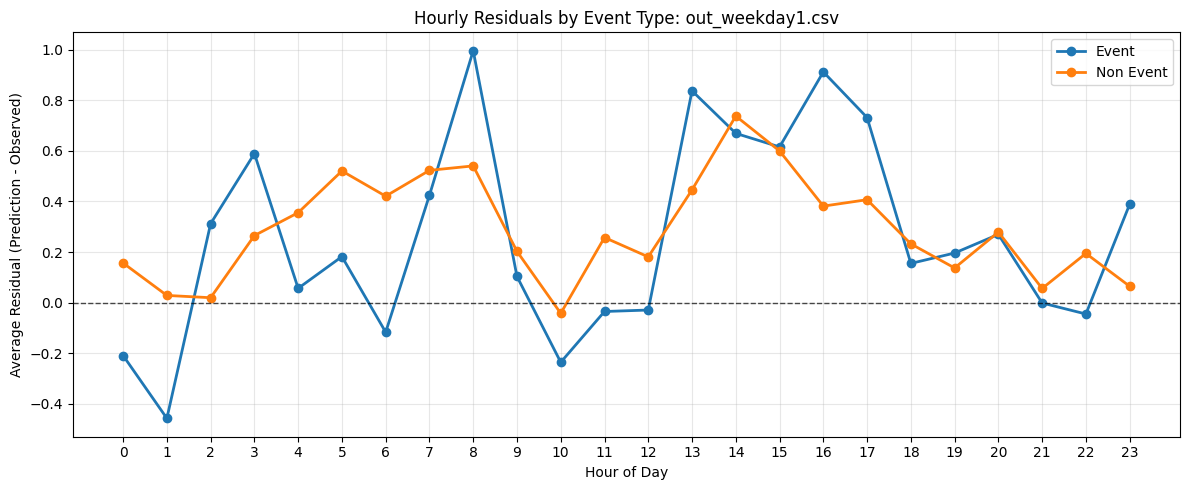

In [12]:
# Plot hourly residuals for event vs non-event

for output_file, hourly_avg in hourly_residual_by_event.items():
    fig, ax = plt.subplots(figsize=(12, 5))

    for event_type, group in hourly_avg.groupby("event_type"):
        ax.plot(
            group["hour_of_day"],
            group["residual"],
            marker="o",
            linewidth=2,
            label=event_type.replace("_", " ").title(),
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xticks(range(24))
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Average Residual (Prediction - Observed)")
    ax.set_title(f"Hourly Residuals by Event Type: {output_file}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
